In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout

In [2]:
df = pd.read_csv("C:/Users/MSI PC/Downloads/Dataset-SA.csv.zip")

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [3]:
df.shape

(205052, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [5]:
df['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [6]:
df = df[['Review','Sentiment']]
df.head()

,Review,Sentiment
0,super!,positive
1,awesome,positive
2,fair,positive
3,useless product,negative
4,fair,neutral


In [7]:
df = df[df['Sentiment'] != 'neutral']

In [8]:
df['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Review       23236
Sentiment        0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
def clean_text(text):

    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)
    
    text = re.sub(r"\d+", "", text)
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    text = text.strip()
    
    return text

In [12]:
df['clean_review'] = df['Review'].apply(clean_text)

In [13]:
pos = df[df['Sentiment'] == 'positive']
neg = df[df['Sentiment'] == 'negative']

neg = neg.sample(len(pos), replace=True, random_state=42)

df = pd.concat([pos, neg])

In [14]:
df = df.sample(frac=1, random_state=42)

In [15]:
df['Sentiment'].value_counts()

Sentiment
positive    147176
negative    147176
Name: count, dtype: int64

In [16]:
# df['clean_review'] = df['Review'].apply(clean_text)

In [17]:
df['Sentiment'] = df['Sentiment'].map({
    'positive':1,
    'negative':0
})

In [18]:
X = df['clean_review']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

In [20]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [21]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [22]:
model = Sequential()

model.add(Embedding(max_words, 128, input_length=max_len))

model.add(GlobalAveragePooling1D())

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

C:\Users\MSI PC\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8353 - loss: 0.3522 - val_accuracy: 0.8830 - val_loss: 0.3148
Epoch 2/5
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9017 - loss: 0.2490 - val_accuracy: 0.9018 - val_loss: 0.2359
Epoch 3/5
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9061 - loss: 0.2408 - val_accuracy: 0.9111 - val_loss: 0.2292
Epoch 4/5
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9084 - loss: 0.2362 - val_accuracy: 0.9112 - val_loss: 0.2271
Epoch 5/5
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9093 - loss: 0.2356 - val_accuracy: 0.9066 - val_loss: 0.2406


In [26]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

1840/1840 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9079 - loss: 0.2393
Test Accuracy: 0.907866358757019


In [27]:
y_pred = model.predict(X_test_pad)

y_pred = (y_pred > 0.5).astype(int)

1840/1840 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


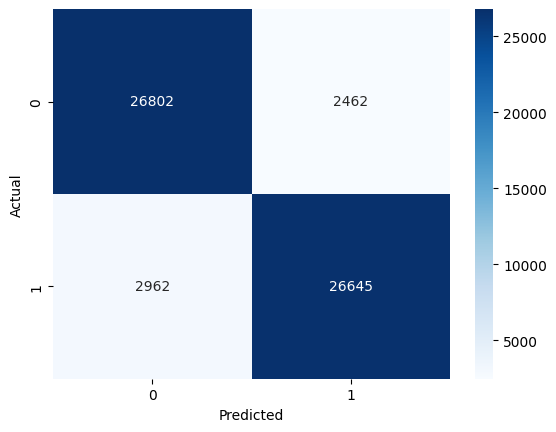

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     29264
           1       0.92      0.90      0.91     29607

    accuracy                           0.91     58871
   macro avg       0.91      0.91      0.91     58871
weighted avg       0.91      0.91      0.91     58871



In [30]:
model.save("sentiment_model.h5")

In [31]:
with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [32]:
def predict_review(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(pad)[0][0]

    if pred >= 0.5:
        return "Positive"
    else:
        return "Negative"

In [33]:
predict_review("This product is amazing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


'Positive'

In [34]:
predict_review("worst quality")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


'Negative'